In [1]:
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from PIL import Image
import numpy as np
import os
import random

In [2]:
coco = COCO(os.path.abspath("../data/for_segmentation/result.json")) # Replace with your file path

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [3]:
# Get all image IDs and pick the first one
img_ids = coco.getImgIds()
img_id = img_ids[random.choice(img_ids)]  # Change index to view different images
print(img_id)

183


In [4]:
img_info = coco.loadImgs(img_id)[0]
img = Image.open(img_info['file_name'])  # Make sure image path is correct

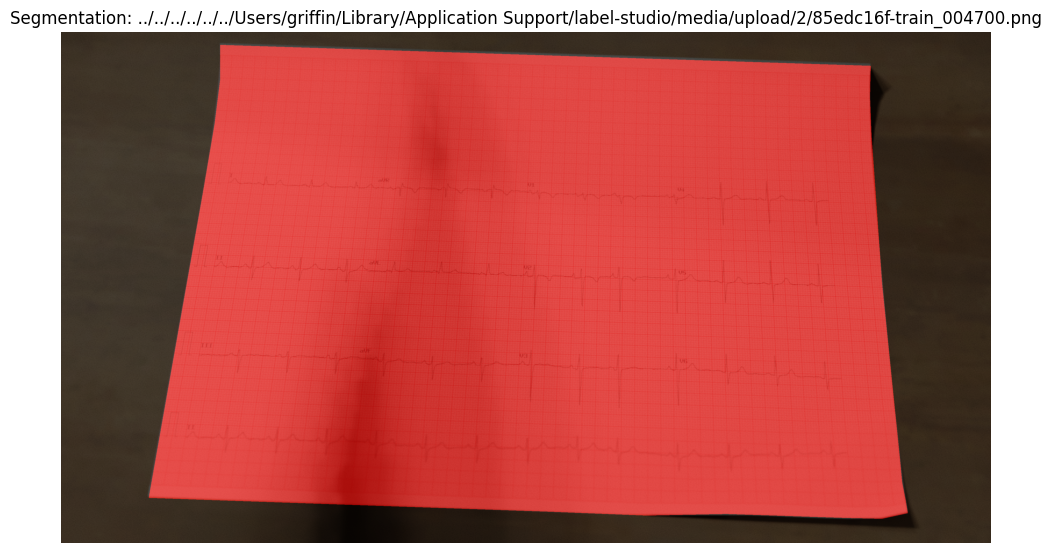

Image: ../../../../../../Users/griffin/Library/Application Support/label-studio/media/upload/2/85edc16f-train_004700.png
Annotation ID: 183, Category ID: 0


In [5]:

# Create plot
plt.figure(figsize=(12, 8))
plt.imshow(img)

# Get the single annotation for this image
ann_ids = coco.getAnnIds(imgIds=img_id)
ann = coco.loadAnns(ann_ids)[0]  # Get the first (and only) annotation

# Convert to mask and plot
mask = coco.annToMask(ann)
color = [1, 0, 0]  # Red color - change to your preference

# Create colored overlay
colored_mask = np.zeros((*mask.shape, 3))
for c in range(3):
    colored_mask[:, :, c] = mask * color[c]

plt.imshow(colored_mask, alpha=0.6)  # Adjust alpha for transparency

plt.axis('off')
plt.title(f'Segmentation: {img_info["file_name"]}')
plt.show()

# Print annotation info
print(f"Image: {img_info['file_name']}")
print(f"Annotation ID: {ann['id']}, Category ID: {ann['category_id']}")